# Assignment 2.2: Non-Linear Transformations - Power-Law (Gamma) Correction

### 1. Import Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### 2. Load Image Using OpenCV

In [3]:
# Path to input image
image_path = "../assets/input/sample.jpg"

# Read image using OpenCV
image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError(f"Could not load image: {image_path}")

# Convert BGR to RGB for Matplotlib
image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

print("Image shape:", image_rgb.shape)
print("Image data type:", image_rgb.dtype)

Image shape: (480, 640, 3)
Image data type: uint8


### 3. Display Original Image

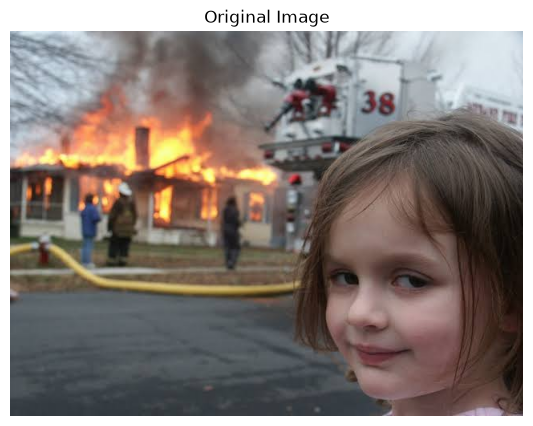

In [4]:
plt.figure(figsize=(7, 5))

plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.show()

### 4. Power-Law Transformation Function

In [5]:
def gamma_correction(image, gamma, c=1.0):

    # Normalize pixel values to [0, 1]
    r = image.astype(np.float32) / 255.0

    # Apply power-law transformation
    s = c * np.power(r, gamma)

    # Convert back to [0, 255]
    output = np.clip(
        s * 255.0,
        0,
        255
    ).astype(np.uint8)

    return output

**Gamma < 1**

When: $$ 0 < \gamma < 1 $$

the darker intensity values are expanded, making the image brighter.

### 5. Gamma Correction with γ = 0.5

In [6]:
gamma = 0.5

gamma_05 = gamma_correction(
    image,
    gamma
)

gamma_05_rgb = cv2.cvtColor(
    gamma_05,
    cv2.COLOR_BGR2RGB
)

### 6. Display γ = 0.5

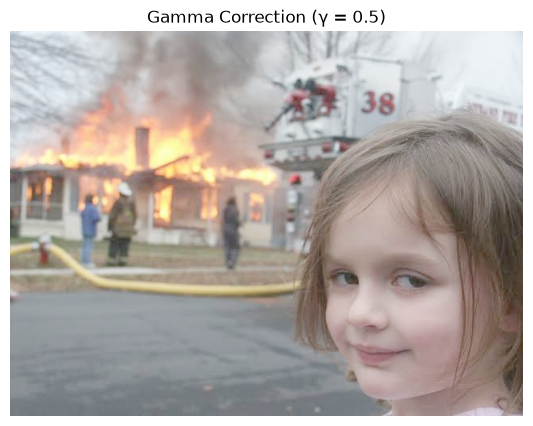

In [7]:
plt.figure(figsize=(7, 5))

plt.imshow(gamma_05_rgb)
plt.title("Gamma Correction (γ = 0.5)")
plt.axis("off")

plt.show()

**Gamma = 1**

When:

$$ \gamma = 1 $$

the transformation becomes:

$$ s = r $$

so the image remains unchanged.

### 7. Gamma = 1

In [8]:
gamma = 1.0

gamma_1 = gamma_correction(
    image,
    gamma
)

gamma_1_rgb = cv2.cvtColor(
    gamma_1,
    cv2.COLOR_BGR2RGB
)

### 8. Display γ = 1

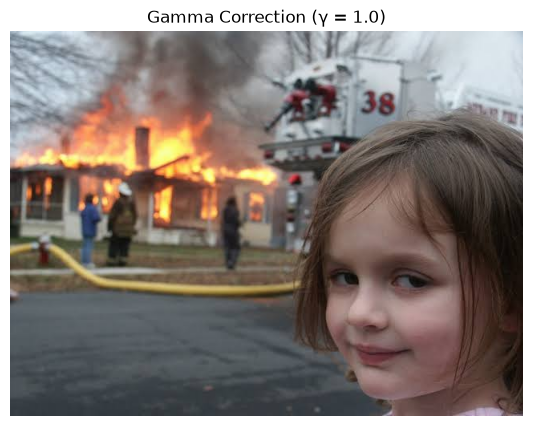

In [9]:
plt.figure(figsize=(7, 5))

plt.imshow(gamma_1_rgb)
plt.title("Gamma Correction (γ = 1.0)")
plt.axis("off")

plt.show()

**Gamma > 1**

When: $$ \gamma > 1 $$

the darker intensity values are compressed, making the image darker.

### 9. Gamma Correction with γ = 2.0

In [10]:
gamma = 2.0

gamma_2 = gamma_correction(
    image,
    gamma
)

gamma_2_rgb = cv2.cvtColor(
    gamma_2,
    cv2.COLOR_BGR2RGB
)

### 10. Display γ = 2.0

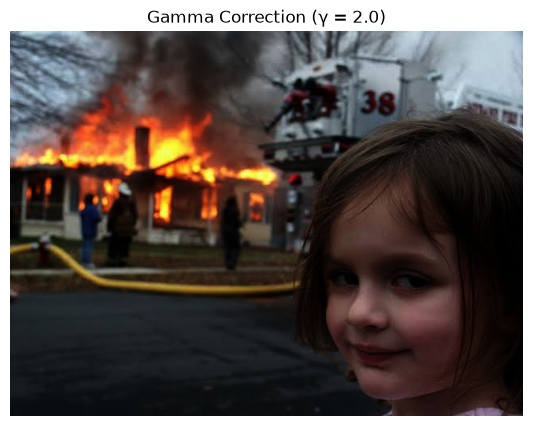

In [11]:
plt.figure(figsize=(7, 5))

plt.imshow(gamma_2_rgb)
plt.title("Gamma Correction (γ = 2.0)")
plt.axis("off")

plt.show()

### 11. Display Comparison

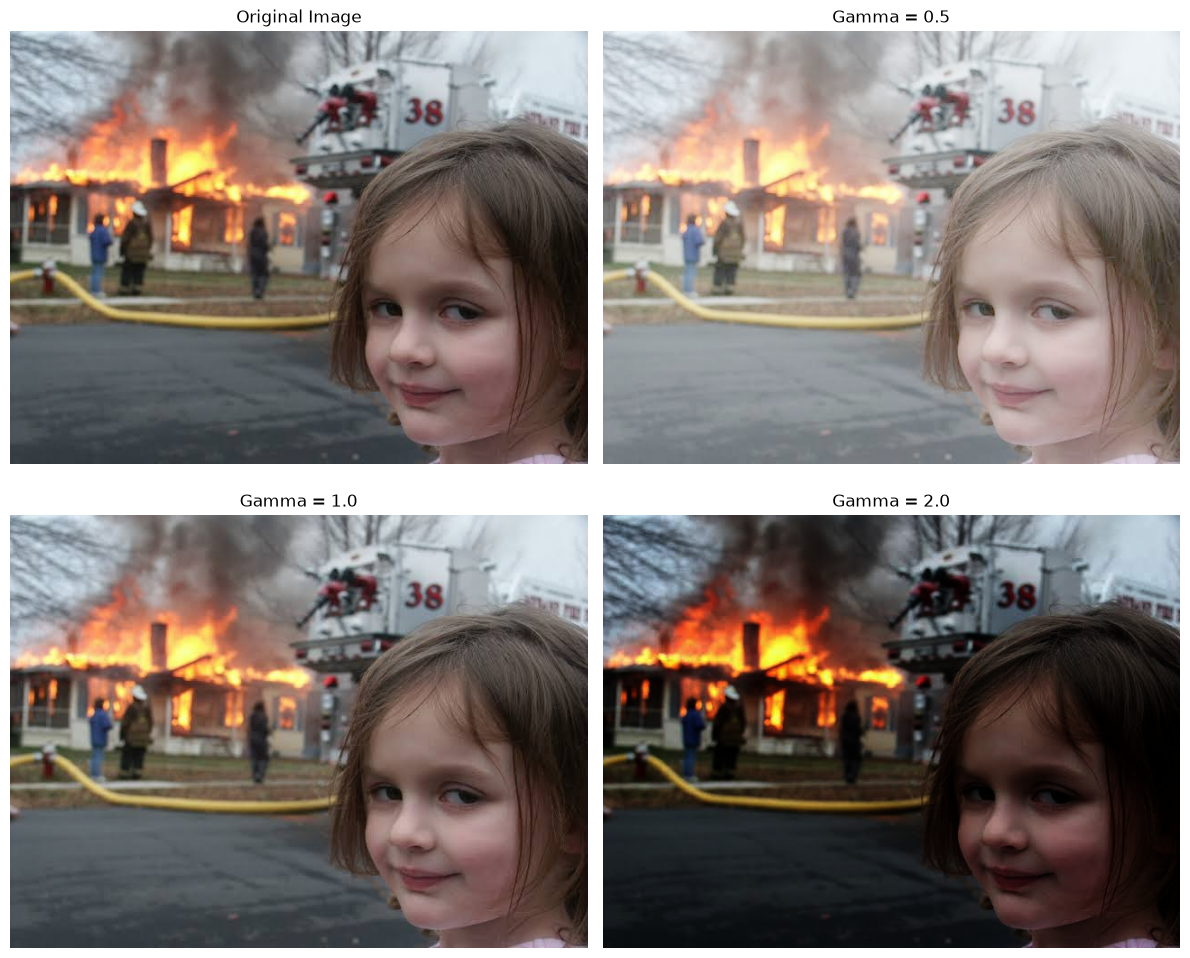

In [12]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10)
)

# Original
axes[0, 0].imshow(image_rgb)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("off")

# Gamma = 0.5
axes[0, 1].imshow(gamma_05_rgb)
axes[0, 1].set_title("Gamma = 0.5")
axes[0, 1].axis("off")

# Gamma = 1.0
axes[1, 0].imshow(gamma_1_rgb)
axes[1, 0].set_title("Gamma = 1.0")
axes[1, 0].axis("off")

# Gamma = 2.0
axes[1, 1].imshow(gamma_2_rgb)
axes[1, 1].set_title("Gamma = 2.0")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

### 12. Gamma Transformation Curves

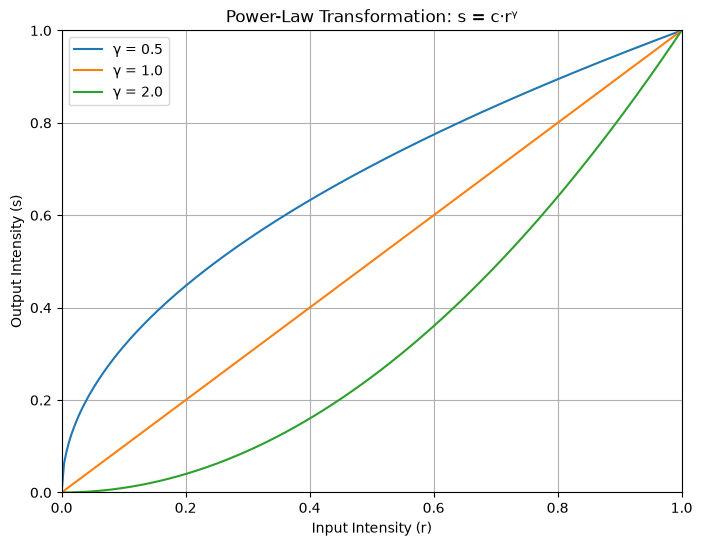

In [13]:
# Normalized input intensity
r = np.linspace(
    0,
    1,
    256
)

# Different gamma values
gamma_values = [
    0.5,
    1.0,
    2.0
]

plt.figure(figsize=(8, 6))

for gamma in gamma_values:

    s = np.power(
        r,
        gamma
    )

    plt.plot(
        r,
        s,
        label=f"γ = {gamma}"
    )

plt.xlabel("Input Intensity (r)")
plt.ylabel("Output Intensity (s)")
plt.title("Power-Law Transformation: s = c·rᵞ")

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.grid()
plt.legend()

plt.show()